<a href="https://colab.research.google.com/github/midhun-babu/Airline-Passenger-Satisfaction/blob/main/Airline_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import os
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
print(path)
print(os.listdir(path))

train = pd.read_csv(os.path.join(path, 'train.csv'))
test = pd.read_csv(os.path.join(path, 'test.csv'))

print(train.shape, test.shape)
train.head()

Using Colab cache for faster access to the 'airline-passenger-satisfaction' dataset.
/kaggle/input/airline-passenger-satisfaction
['train.csv', 'test.csv']
(103904, 25) (25976, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


inspect

In [18]:
train.info()
print(train.isnull().sum()[train.isnull().sum() > 0])
print("Duplicates:", train.duplicated().sum())
train['satisfaction'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

,proportion
satisfaction,
neutral or dissatisfied,0.566667
satisfied,0.433333


clean


In [19]:
# reload raw files so this cell can be re-run safely
train = pd.read_csv(os.path.join(path, 'train.csv'))
test = pd.read_csv(os.path.join(path, 'test.csv'))

# tidy the column names
for df in (train, test):
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# drop the index and id columns
for df in (train, test):
    df.drop(columns=[c for c in ['unnamed:_0', 'id'] if c in df.columns], inplace=True)

# arrival delay has a few nulls; fill with the train median
median_delay = train['arrival_delay_in_minutes'].median()
for df in (train, test):
    df['arrival_delay_in_minutes'] = df['arrival_delay_in_minutes'].fillna(median_delay)

# binary target for easier maths
train['satisfied'] = (train['satisfaction'] == 'satisfied').astype(int)
test['satisfied'] = (test['satisfaction'] == 'satisfied').astype(int)

print(train.shape, test.shape)
print(train.isnull().sum().sum(), "nulls left")

(103904, 24) (25976, 24)
0 nulls left


first business question, satisfaction by class and travel type


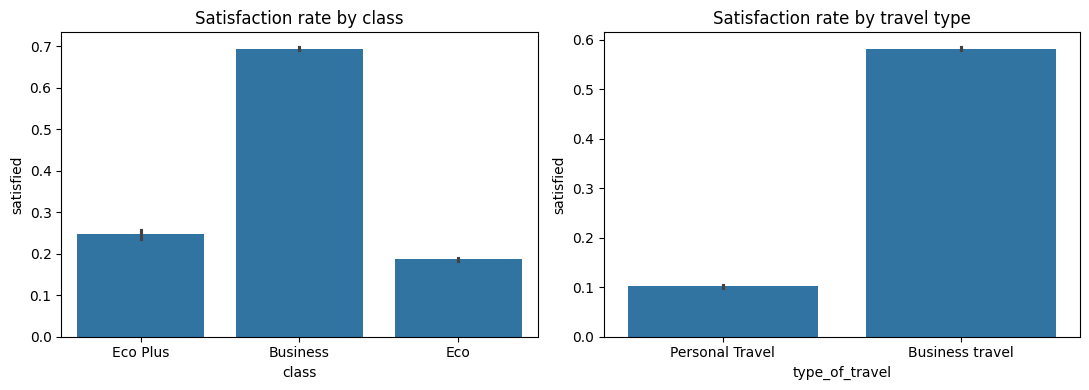

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=train, x='class', y='satisfied', ax=ax[0])
ax[0].set_title('Satisfaction rate by class')
sns.barplot(data=train, x='type_of_travel', y='satisfied', ax=ax[1])
ax[1].set_title('Satisfaction rate by travel type')
plt.tight_layout()
plt.show()

which services matter, correlation with satisfaction


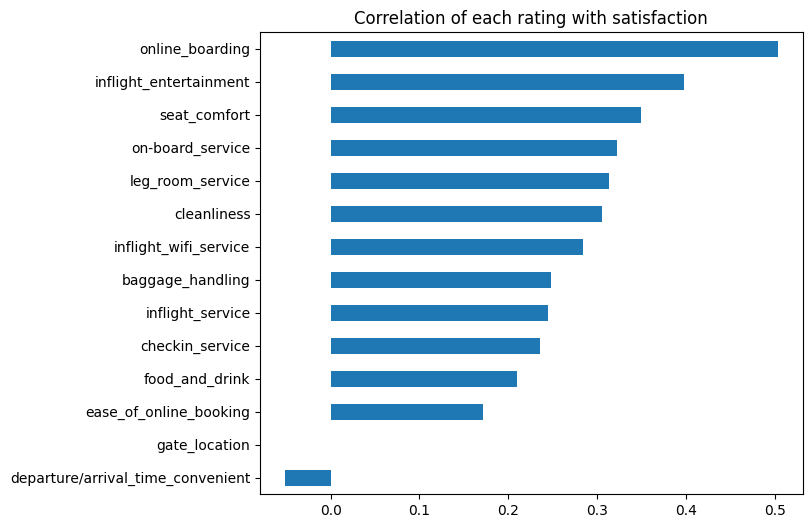

In [8]:
ratings = ['inflight_wifi_service','departure/arrival_time_convenient','ease_of_online_booking',
           'gate_location','food_and_drink','online_boarding','seat_comfort',
           'inflight_entertainment','on-board_service','leg_room_service',
           'baggage_handling','checkin_service','inflight_service','cleanliness']

train[ratings + ['satisfied']].corr()['satisfied'].drop('satisfied').sort_values().plot(
    kind='barh', figsize=(7,6), title='Correlation of each rating with satisfaction')
plt.show()

do delays hurt satisfaction?

                  mean  count
delay_bucket                 
No delay      0.457524  58668
1-15 min      0.436576  22184
16-60 min     0.373806  15813
61-120 min    0.355608   4699
120+ min      0.360630   2540


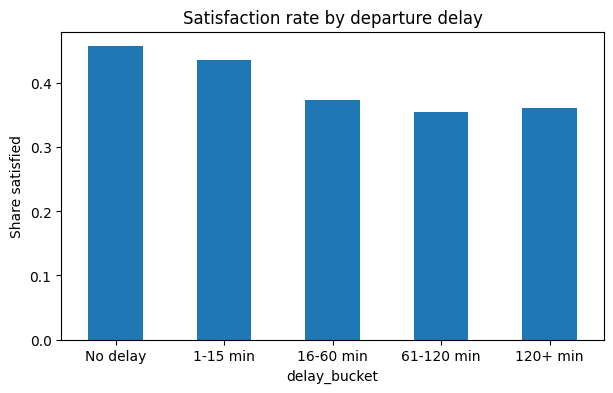

In [10]:
bins = [-1, 0, 15, 60, 120, float('inf')]
labels = ['No delay', '1-15 min', '16-60 min', '61-120 min', '120+ min']
train['delay_bucket'] = pd.cut(train['departure_delay_in_minutes'], bins=bins, labels=labels)

delay_rate = train.groupby('delay_bucket', observed=True)['satisfied'].agg(['mean', 'count'])
print(delay_rate)

delay_rate['mean'].plot(kind='bar', figsize=(7,4), title='Satisfaction rate by departure delay')
plt.ylabel('Share satisfied')
plt.xticks(rotation=0)
plt.show()

loyal vs disloyal, and by class

customer_type
Loyal Customer       0.477291
disloyal Customer    0.236658
Name: satisfied, dtype: float64


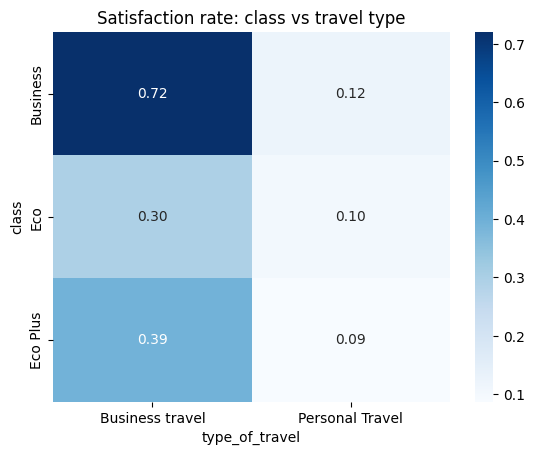

In [9]:
print(train.groupby('customer_type')['satisfied'].mean())

pivot = train.pivot_table(values='satisfied', index='class', columns='type_of_travel', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Blues')
plt.title('Satisfaction rate: class vs travel type')
plt.show()

age and flight distance

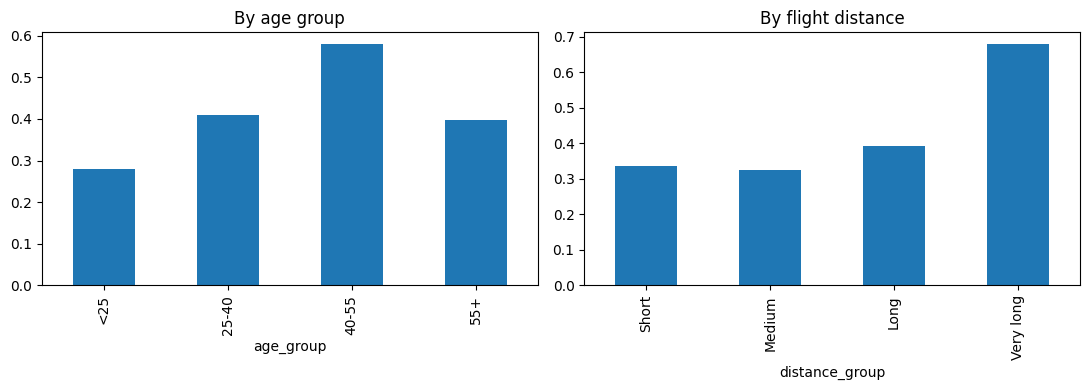

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

train['age_group'] = pd.cut(train['age'], [0, 25, 40, 55, 100], labels=['<25', '25-40', '40-55', '55+'])
train.groupby('age_group', observed=True)['satisfied'].mean().plot(kind='bar', ax=ax[0], title='By age group')

train['distance_group'] = pd.qcut(train['flight_distance'], 4, labels=['Short', 'Medium', 'Long', 'Very long'])
train.groupby('distance_group', observed=True)['satisfied'].mean().plot(kind='bar', ax=ax[1], title='By flight distance')

plt.tight_layout()
plt.show()

prepare features


In [12]:
drop_cols = ['satisfaction', 'satisfied', 'delay_bucket', 'age_group', 'distance_group']

X_train = pd.get_dummies(train.drop(columns=drop_cols), drop_first=True)
y_train = train['satisfied']

X_test = pd.get_dummies(test.drop(columns=[c for c in drop_cols if c in test.columns]), drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
y_test = test['satisfied']

print(X_train.shape, X_test.shape)

(103904, 23) (25976, 23)


baseline, logistic regression

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)

print("Logistic regression accuracy:", round(accuracy_score(y_test, pred_lr), 4))
print(classification_report(y_test, pred_lr))

Logistic regression accuracy: 0.8716
              precision    recall  f1-score   support

           0       0.87      0.90      0.89     14573
           1       0.87      0.83      0.85     11403

    accuracy                           0.87     25976
   macro avg       0.87      0.87      0.87     25976
weighted avg       0.87      0.87      0.87     25976



random forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random forest accuracy:", round(accuracy_score(y_test, pred_rf), 4))
print(classification_report(y_test, pred_rf))

Random forest accuracy: 0.9625
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



what drives satisfaction

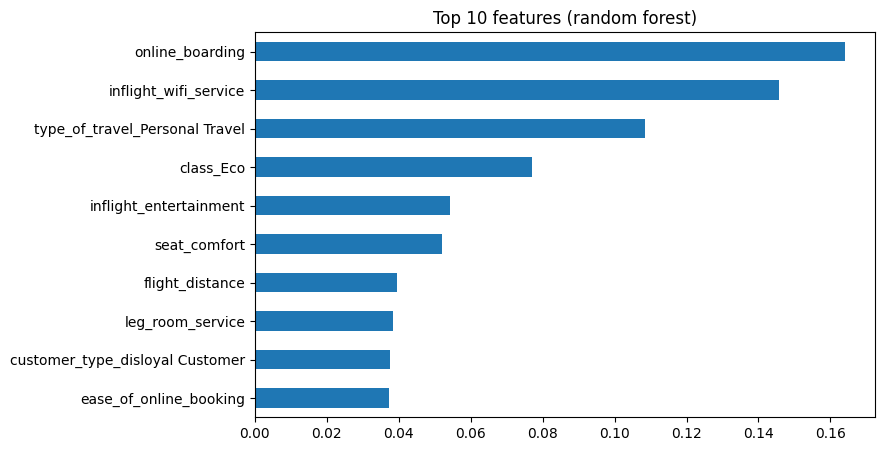

In [15]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()
importances.tail(10).plot(kind='barh', figsize=(8,5), title='Top 10 features (random forest)')
plt.show()

confusion matrix

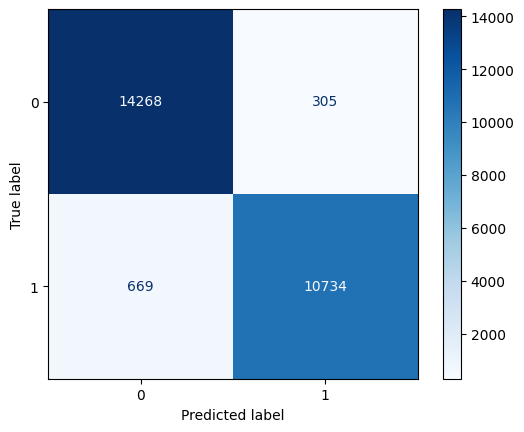

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, cmap='Blues')
plt.show()